# Lab 6 — Machine Learning Supervisado: Comparación de Algoritmos

**Curso:** BE3006 · Análisis de Datos Biomédicos · UVG
**Referencia:** Clase 11 — Machine Learning I
**Lab previo:** Lab 4 — Modelado Estadístico

---

## ¿De qué se trata este lab?

En Lab 4 construiste tu primer modelo predictivo (regresión logística) con datos sintéticos de 108 pacientes. Aprendiste el flujo completo: feature engineering, train/test split, cross-validation, ROC/AUC, data leakage.

Ahora damos dos pasos adelante:

1. **Algoritmos nuevos**: además de regresión logística, vas a usar **árboles de decisión, Random Forest y SVM**.
2. **Dataset clínico real**: dejamos atrás Synthea. Trabajaremos con **20,000 encuentros** del UCI *Diabetes 130-US Hospitals* (1999–2008), prediciendo **readmisión hospitalaria a 30 días**.

La segunda mitad del lab es **semi-libre**: construyes tu propio modelo para un *validation set* que no has visto, y compites por el mejor AUC.

### Objetivos de aprendizaje

Al completar este lab podrás:

1. Entrenar y comparar **logística, árbol de decisión, Random Forest y SVM** en un mismo problema clínico
2. Entender **cómo funciona cada algoritmo internamente** (seguir un paciente por un árbol, contar votos de un forest)
3. Leer **feature importance** para priorizar variables clínicamente relevantes
4. Reconocer cuándo un algoritmo complejo **no mejora** significativamente sobre uno simple
5. Elegir un modelo y **justificar** la decisión en términos clínicos

---

### Estructura del lab

| Parte | Tema | Tipo |
|-------|------|------|
| 0 | Setup y carga de datos | Guiado |
| 1 | EDA orientada al modelo | Guiado + ejercicio |
| 2 | Preprocessing compartido | Guiado |
| 3 | Baseline: regresión logística | Guiado + ejercicio |
| 4 | Árbol de decisión | Guiado + ejercicios |
| 5 | Random Forest | Guiado + ejercicios |
| 6 | SVM | Guiado + ejercicio |
| 7 | **Tu mejor modelo** | Semi-libre |
| 8 | Reflexión final | Preguntas abiertas |

### Sobre la entrega

Además del notebook, entregas un archivo `predictions_<tuapellido>.csv` con las probabilidades de tu mejor modelo sobre un *validation set* oculto de 2,000 encuentros. Los mejores AUC recibirán mejor nota.

---
## Parte 0: Setup y carga de datos

Importamos librerías en tres grupos:

- **Datos y visualización:** `pandas`, `numpy`, `matplotlib`, `seaborn`
- **Machine learning:** `scikit-learn` — modelos, métricas, herramientas de validación
- **Utilidades:** `pathlib`, `warnings`

In [1]:
# ── Datos y visualización ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Machine Learning ──
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay, RocCurveDisplay,
)

# ── Configuración de gráficos ──
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


### Carga de datos

Cargamos dos archivos:

| Archivo | Contenido | Filas |
|---|---|---|
| `public_train.csv` | Encuentros **con** outcome (para entrenar y validar internamente) | 20,000 |
| `validation_features.csv` | Encuentros **sin** outcome (tu modelo predice sobre este set) | 2,000 |

### Contexto clínico

**Readmisión hospitalaria a 30 días** es un problema real y costoso. En EE.UU., el programa HRRP de Medicare penaliza a los hospitales con tasas altas de readmisión para condiciones específicas. Un modelo predictivo confiable permite:

- Identificar pacientes de alto riesgo al alta
- Asignar recursos de seguimiento (llamadas, visitas domiciliarias)
- Reducir costos evitables (~\$17B anuales en EE.UU.)

Nuestro outcome binario es: **¿el paciente fue readmitido en menos de 30 días?** (1 = sí, 0 = no).

In [2]:
DATA = Path("../data")

train = pd.read_csv(DATA / "public_train.csv")
X_validation = pd.read_csv(DATA / "validation_features.csv")

print(f"train:           {train.shape}")
print(f"X_validation:    {X_validation.shape}")
print(f"\nColumnas en train: {len(train.columns)}")
print(f"Columnas en validation: {len(X_validation.columns)}  (sin 'target')")

train.head()

train:           (20000, 46)
X_validation:    (2000, 45)

Columnas en train: 46
Columnas en validation: 45  (sin 'target')


,encounter_id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,enc_t_00001,Caucasian,Male,[80-90),2,1,4,1,1,2,...,No,No,No,No,No,No,No,Ch,Yes,0
1,enc_t_00002,AfricanAmerican,Female,[70-80),1,3,7,5,34,3,...,No,Steady,No,No,No,No,No,No,Yes,1
2,enc_t_00003,Caucasian,Female,[70-80),1,3,7,2,56,1,...,No,No,No,No,No,No,No,No,No,0
3,enc_t_00004,Caucasian,Male,[60-70),1,1,7,3,48,1,...,No,Steady,No,No,No,No,No,No,Yes,1
4,enc_t_00005,Caucasian,Male,[70-80),3,1,1,6,21,2,...,No,No,No,No,No,No,No,No,No,0


### Separar features y outcome

El `encounter_id` es solo un identificador — no va al modelo. El `target` es lo que queremos predecir.

In [3]:
# X = features (sin target ni identificador)
# y = outcome
X = train.drop(columns=['encounter_id', 'target'])
y = train['target']

print(f"X shape: {X.shape}")
print(f"y distribución: \n{y.value_counts()}")
print(f"Prevalencia de readmisión <30d: {y.mean():.1%}")

X shape: (20000, 44)
y distribución: 
target
0    17765
1     2235
Name: count, dtype: int64
Prevalencia de readmisión <30d: 11.2%


---
## Parte 1: EDA orientada al modelo

El EDA aquí es más corto que en Lab 4 porque el objetivo es diferente: no buscamos insights clínicos profundos, buscamos entender **qué preprocessing necesitan los datos**.

Tres preguntas rápidas:

1. ¿Está balanceado el outcome?
2. ¿Hay missing values que necesitamos imputar?
3. ¿Cuántas columnas numéricas y cuántas categóricas tenemos?

1. No, está muy desbalanceado debido a que hay 88.8% de pacientes no readmitidos, mientras que solo un 11.2% de encuentros que sí fueron readmitidos en menos de 30 días.
2. Sí, hay muchos valores que falten en 3 columnas (max_glu_serum, A1Cresult y race). Se infier que por los porcentajes altos de datos faltantes, los tests de glucosa sugieren que no se realizaron de forma rutinaria a todos los pacientes.
3. Hay 11 numéricas y 33 categóricas.

### 1.1 Balance del outcome

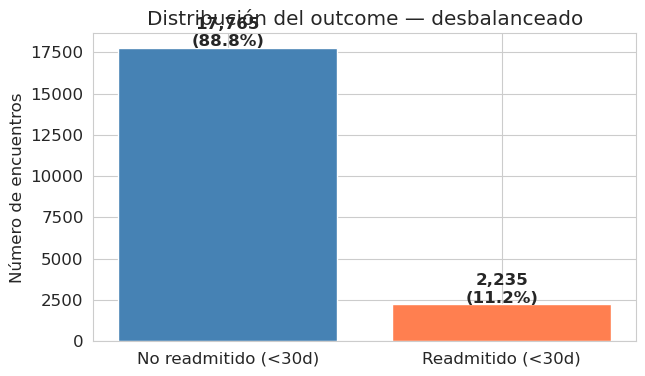

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = y.value_counts()
ax.bar(['No readmitido (<30d)', 'Readmitido (<30d)'], counts.values,
       color=['steelblue', 'coral'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, f'{v:,}\n({v/len(y):.1%})', ha='center', fontweight='bold')
ax.set_ylabel('Número de encuentros')
ax.set_title('Distribución del outcome — desbalanceado')
plt.show()

### 1.2 Missing values por columna

Listamos las columnas con datos faltantes.

In [5]:
missing = X.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(X) * 100).round(1)
pd.DataFrame({'missing': missing, 'porcentaje': missing_pct})

,missing,porcentaje
max_glu_serum,18956,94.8
A1Cresult,16665,83.3
race,453,2.3


### 1.3 Columnas numéricas vs categóricas

Esta distinción importa porque cada tipo necesita su propio preprocessing:
- **Numéricas** → imputar + escalar
- **Categóricas** → imputar + one-hot encoding

In [6]:
num_features = X.select_dtypes(include=['number']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Features numéricas ({len(num_features)}):")
for c in num_features:
    print(f"  - {c}")

print(f"\nFeatures categóricas ({len(cat_features)}):")
for c in cat_features[:10]:
    print(f"  - {c}")
if len(cat_features) > 10:
    print(f"  ... y {len(cat_features)-10} más")

Features numéricas (11):
  - admission_type_id
  - discharge_disposition_id
  - admission_source_id
  - time_in_hospital
  - num_lab_procedures
  - num_procedures
  - num_medications
  - number_outpatient
  - number_emergency
  - number_inpatient
  - number_diagnoses

Features categóricas (33):
  - race
  - gender
  - age
  - diag_1
  - diag_2
  - diag_3
  - max_glu_serum
  - A1Cresult
  - metformin
  - repaglinide
  ... y 23 más


### 1.4 Correlación de features numéricas con el outcome

Nos da una primera intuición de qué variables podrían ser predictivas. Correlación no implica causalidad — es solo un vistazo preliminar.

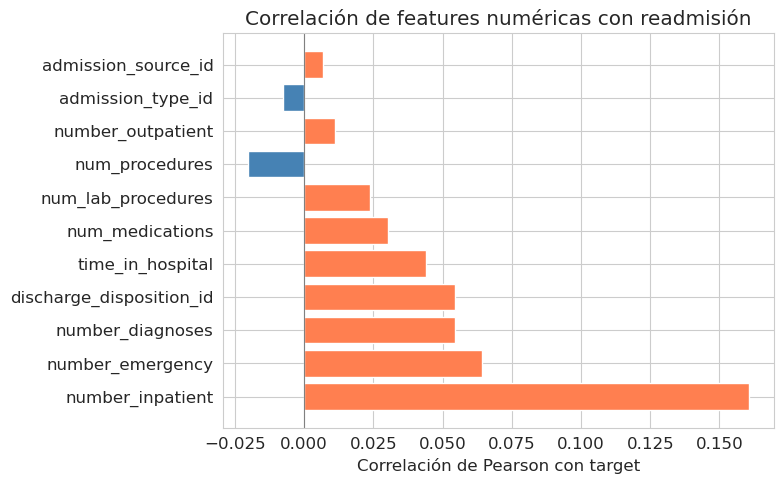


Las correlaciones son BAJAS en magnitud (<0.1). Esto ya adelanta que
el problema es difícil: ninguna variable por sí sola predice readmisión.


In [7]:
correlations = X[num_features].corrwith(y).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['coral' if c > 0 else 'steelblue' for c in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con target')
ax.set_title('Correlación de features numéricas con readmisión')
plt.tight_layout()
plt.show()

print("\nLas correlaciones son BAJAS en magnitud (<0.1). Esto ya adelanta que")
print("el problema es difícil: ninguna variable por sí sola predice readmisión.")

**Ejercicio 1.1 (pregunta abierta — responde en el siguiente markdown):**

El outcome está desbalanceado (~11% positivos). En 2–3 oraciones:

- ¿Por qué la **accuracy** será engañosa en este lab?
- ¿Por qué **AUC** es más informativa que accuracy en este caso?

1. Debido a que si aproximadamente el 89% de los pacientes no son readmitidos sin haber aprendido nada antes entonces su precisión puede verse como no verídica. En el ámbito médico esto es de suma importancia porque se desea tener un modelo no perezoso y preciso para salvar la vida de las personas.
2. El AUC es superior porque mide la capacidad del modelo para ordenar o clasificar a los pacientes por riesgo, independientemente de un umbral fijo. Evalúa qué tan bien el modelo distingue entre un paciente que será readmitido y uno que no, lo cual es vital en este lab para comparar algoritmos sin sesgarse por el hecho de que la clase positiva sea minoritaria.

**CHECKPOINT 1** — Haz commit de tu progreso:
```bash
git add -A && git commit -m "Checkpoint 1: EDA complete"
```

---

## Parte 2: Preprocessing compartido — la clave del lab

Todos los modelos que entrenemos hoy necesitan **el mismo preprocessing**:

| Tipo de feature | Pasos |
|---|---|
| Numérica | Imputar (mediana) → escalar (StandardScaler) |
| Categórica | Imputar (moda) → OneHotEncoder |

En vez de escribirlo cada vez, definimos **dos funciones** que vamos a usar durante todo el lab. Entenderlas bien ahora te ahorra pensar en preprocessing después.

### 2.1 `build_pipeline(model)` — construye un pipeline con preprocessing + modelo

In [9]:
def build_pipeline(model):
    """
    Construye un pipeline con preprocessing estándar + el modelo que pases.

    Úsala para TODOS los modelos del lab. El preprocessing detecta
    automáticamente qué columnas son numéricas y cuáles categóricas.

    Parámetros:
    - model: cualquier estimador de sklearn (LogisticRegression, RF, etc.)

    Retorna: Pipeline entrenable con .fit() y .predict_proba()
    """
    num_features = X.select_dtypes(include=['number']).columns.tolist()
    cat_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', max_categories=20)),
        ]), cat_features),
    ])

    return Pipeline([('prep', preprocessor), ('model', model)])

print("build_pipeline lista.")

build_pipeline lista.


### 2.2 `evaluate(model)` — evalúa con cross-validation estratificada

Esta función entrena `model` con **CV de 5 folds estratificada** (cada fold mantiene la proporción 11% positivos) y reporta el AUC promedio con su desviación estándar.

In [10]:
def evaluate(model, cv=5):
    """
    Evalúa un modelo con CV estratificada y reporta AUC promedio ± std.

    Parámetros:
    - model: estimador de sklearn (sin pipeline — esta función se lo agrega)
    - cv: número de folds (default 5)

    Retorna: array con los AUCs de cada fold (para comparaciones después)
    """
    pipe = build_pipeline(model)
    splitter = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X, y, cv=splitter,
                              scoring='roc_auc', n_jobs=-1)
    print(f"AUC: {scores.mean():.3f} ± {scores.std():.3f}   "
          f"(folds: {', '.join(f'{s:.3f}' for s in scores)})")
    return scores

print("evaluate lista. Regla del lab: usar SIEMPRE esta función para comparar modelos.")

evaluate lista. Regla del lab: usar SIEMPRE esta función para comparar modelos.


**CHECKPOINT 2** — Haz commit de tu progreso:
```bash
git add -A && git commit -m "Checkpoint 2: preprocessing utilities ready"
```

---

## Parte 3: Baseline — regresión logística

Ya dominas logística desde Lab 4. Aquí la usamos como **piso**: cualquier modelo más complejo debe superarla para justificar su costo computacional.

### 3.1 Logística con CV

In [13]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg_scores = evaluate(logreg)

AUC: 0.630 ± 0.009   (folds: 0.631, 0.631, 0.634, 0.642, 0.615)


### 3.2 Matriz de confusión y curva ROC en un holdout

Dividimos el train público 80/20 para tener una vista "realista" de performance. Mostramos la matriz de confusión al umbral 0.5 y la curva ROC.

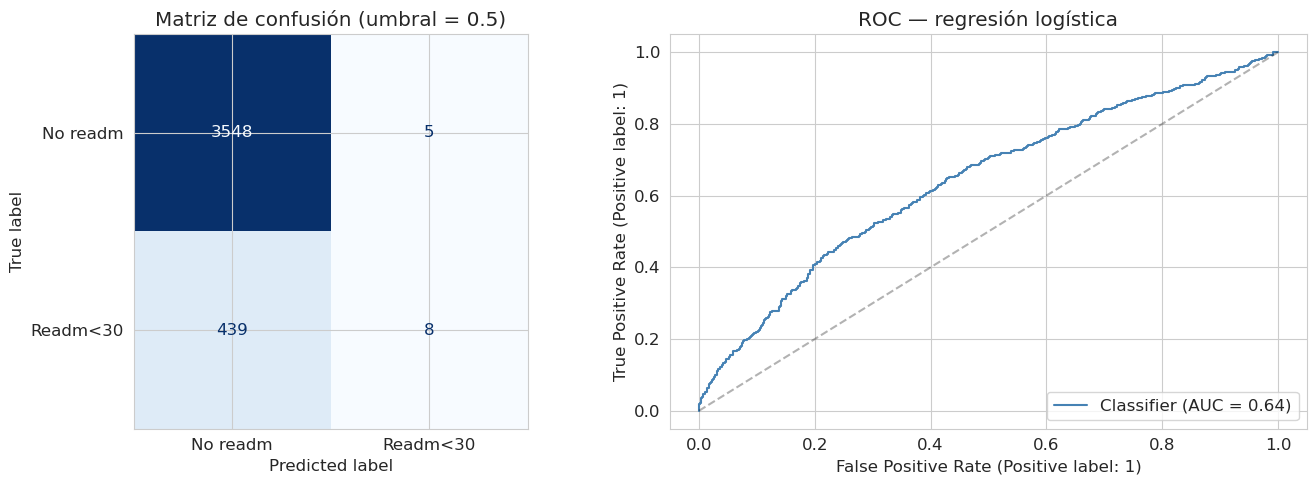


AUC holdout: 0.641

Observación clave: con umbral 0.5, el modelo predice casi todo como 'no readmitido'.
Esto es típico en outcomes desbalanceados. En Parte 7 veremos cómo ajustar el umbral.


In [14]:
# Holdout 80/20 (estratificado)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

logreg_pipe = build_pipeline(LogisticRegression(max_iter=1000, random_state=42))
logreg_pipe.fit(X_tr, y_tr)
proba_te = logreg_pipe.predict_proba(X_te)[:, 1]
pred_te = (proba_te >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_te, pred_te)
ConfusionMatrixDisplay(cm, display_labels=['No readm', 'Readm<30']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title(f'Matriz de confusión (umbral = 0.5)')

# ROC
RocCurveDisplay.from_predictions(y_te, proba_te, ax=axes[1], color='steelblue')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('ROC — regresión logística')

plt.tight_layout()
plt.show()

print(f"\nAUC holdout: {roc_auc_score(y_te, proba_te):.3f}")
print(f"\nObservación clave: con umbral 0.5, el modelo predice casi todo como 'no readmitido'.")
print("Esto es típico en outcomes desbalanceados. En Parte 7 veremos cómo ajustar el umbral.")

**Ejercicio 3.1:**

Anota el AUC de CV que obtuviste con la logística base — ése es tu **piso**. Cualquier modelo más complejo que pruebes hoy tiene que superarlo para que valga la pena.

> **Tu AUC baseline:** 0.630 ± 0.009

**CHECKPOINT 3** — Haz commit de tu progreso:
```bash
git add -A && git commit -m "Checkpoint 3: baseline logistico complete"
```

---

## Parte 4: Árbol de decisión

Un árbol divide el espacio de features en regiones rectangulares a través de preguntas secuenciales ("¿`time_in_hospital > 3.5`?"). Cada región (hoja) tiene una predicción asociada.

**Dos árboles con propósitos diferentes:**

- **4a** — un árbol "de juguete" sobre 5 features numéricas, solo para **visualizarlo y seguir a un paciente** (entender el concepto).
- **4b** — el árbol "real" sobre todas las features, para **comparar AUC**.

### 4.1 Árbol visual: 5 features, profundidad 3

Lo entrenamos sin pipeline porque queremos nombres de features legibles en `plot_tree` (no `cat__diag_1_250` sino `time_in_hospital`).

In [ ]:
viz_features = ['time_in_hospital', 'num_medications',
                'num_lab_procedures', 'number_diagnoses', 'num_procedures']

X_viz = X[viz_features].fillna(X[viz_features].median())
tree_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_viz.fit(X_viz, y)

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    tree_viz,
    feature_names=viz_features,
    class_names=['NoReadm', 'Readm<30'],
    filled=True, rounded=True, fontsize=9, ax=ax
)
plt.title('Árbol visual (max_depth=3, 5 features numéricas)')
plt.show()

**Ejercicio 4.1 — Sigue a un paciente por el árbol:**

El siguiente código elige un paciente aleatorio del train y muestra sus 5 features. Tu tarea: sigue manualmente la ruta del árbol (¿`feature <= threshold`? → izquierda; si no → derecha) hasta llegar a una hoja. Compara la probabilidad de la hoja con `tree_viz.predict_proba(paciente)`.

In [ ]:
# Elige un paciente (puedes cambiar el índice para probar con otros)
idx = 0
paciente = X_viz.iloc[[idx]]
print("Features del paciente:")
print(paciente.T)

print(f"\nPredicción del árbol (automática):")
proba = tree_viz.predict_proba(paciente)[0]
print(f"  P(no readmitido) = {proba[0]:.3f}")
print(f"  P(readmitido<30) = {proba[1]:.3f}")

print("\nAhora: sigue manualmente la ruta en el árbol de arriba y verifica.")

### 4.2 Árbol real: todas las features

Ahora usamos `build_pipeline` con todas las features. Es el árbol que vamos a comparar por AUC. No lo visualizamos porque con OHE tiene cientos de ramas ilegibles.

In [ ]:
tree_scores = evaluate(DecisionTreeClassifier(max_depth=5, random_state=42))

**Ejercicio 4.2 — Bias-variance con árboles:**

Entrena tres árboles con distintos `max_depth` y compara sus AUC. Identifica cuál **overfittea** (train muy alto, CV bajo) y cuál está **subajustado** (train y CV ambos bajos).

In [ ]:
for depth in [3, 8, None]:
    print(f"\n=== max_depth = {depth} ===")
    evaluate(DecisionTreeClassifier(max_depth=depth, random_state=42))

**Pregunta 4.3:** En 2–3 oraciones, conecta lo que observaste con el concepto de **bias-variance** que viste en Clase 9.

*Tu respuesta aquí...*

**CHECKPOINT 4** — Haz commit de tu progreso:
```bash
git add -A && git commit -m "Checkpoint 4: arbol complete"
```

---

## Parte 5: Random Forest

Un Random Forest es un **ensemble** de árboles: entrena muchos árboles (100, 200, 500...) cada uno sobre una muestra bootstrap distinta y un subconjunto aleatorio de features. La predicción final es el **promedio** de las predicciones de cada árbol.

**Ventajas frente a un solo árbol:**
- Reduce overfitting drásticamente (varianza menor)
- Da feature importance robusto

**Desventajas:**
- Pierde interpretabilidad (no puedes "seguir a un paciente" por 200 árboles)
- Más costoso en tiempo y memoria

### 5.1 Random Forest base

In [ ]:
rf_scores = evaluate(RandomForestClassifier(
    n_estimators=200, max_depth=10,
    random_state=42, n_jobs=-1
))

### 5.2 ¿Cómo calcula `predict_proba` un Random Forest?

**Mito común:** "RF vota por mayoría — si 73 de 100 árboles dicen clase 1, `predict_proba` es 0.73".

**Realidad:** `RandomForestClassifier.predict_proba(x)` devuelve el **promedio** de `tree.predict_proba(x)` sobre todos los árboles. En hojas puras (profundidad alta), esto coincide con voto por mayoría. En árboles poco profundos con hojas impuras, no.

### Ejercicio 5.1 — Verificar manualmente que `predict_proba` del forest es el promedio de sus árboles

El código siguiente está pre-escrito porque el truco de acceder a `.estimators_` dentro de un pipeline es sutil. Córrelo y observa el resultado.

In [ ]:
# Entrenamos un RF pequeño con pipeline
rf_pipe = build_pipeline(RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42, n_jobs=-1
))
rf_pipe.fit(X_tr, y_tr)  # reusamos el X_tr/y_tr de la Parte 3

# Elegimos un paciente del test set
paciente = X_te.iloc[[0]]

# Extraemos los componentes del pipeline
prep = rf_pipe.named_steps['prep']
rf = rf_pipe.named_steps['model']

# Aplicamos el preprocessing al paciente (mismo que se usó al entrenar)
paciente_prep = prep.transform(paciente)

# Sacamos la probabilidad de clase 1 de CADA árbol y promediamos manualmente
probas_por_arbol = np.array([
    tree.predict_proba(paciente_prep)[0, 1]
    for tree in rf.estimators_
])

print(f"Media manual de árboles:   {probas_por_arbol.mean():.4f}")
print(f"predict_proba del forest:  {rf_pipe.predict_proba(paciente)[0, 1]:.4f}")
print(f"¿Coinciden?  {np.isclose(probas_por_arbol.mean(), rf_pipe.predict_proba(paciente)[0, 1])}")

**En 1–2 oraciones:** ¿Qué te enseña este experimento sobre cómo "vota" un Random Forest?

*Tu respuesta aquí...*

### 5.3 Visualizaciones del Random Forest

Tres gráficas para entender qué hace el forest por dentro.

**(a) Un árbol individual del forest** — muestra que RF = muchos árboles distintos, cada uno entrenado con muestras y features diferentes.

In [ ]:
# Tomamos el primer árbol del forest, truncado a 3 niveles para legibilidad
feature_names_prep = rf_pipe.named_steps['prep'].get_feature_names_out()

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    rf.estimators_[0],
    max_depth=3,
    feature_names=feature_names_prep,
    class_names=['NoReadm', 'Readm<30'],
    filled=True, rounded=True, fontsize=8, ax=ax
)
ax.set_title('Un árbol cualquiera del forest (truncado a 3 niveles)')
plt.show()

**(b) Distribución de predicciones entre los 100 árboles para el paciente anterior** — hace visible la incertidumbre interna del modelo.

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(probas_por_arbol, bins=20, color='steelblue',
         edgecolor='white', alpha=0.85)
plt.axvline(probas_por_arbol.mean(), color='coral', linestyle='--',
            linewidth=2.5,
            label=f'Media = predict_proba = {probas_por_arbol.mean():.3f}')
plt.xlabel('Probabilidad de readmisión predicha por cada árbol')
plt.ylabel('Número de árboles')
plt.title('¿En qué se ponen de acuerdo los 100 árboles del forest?\n(paciente de ejemplo)')
plt.legend()
plt.tight_layout()
plt.show()

**(c) Feature importance del Random Forest — top 15**

¿Qué variables está usando el forest para decidir? Esta es **una de las gráficas más útiles clínicamente** — te permite priorizar qué variables son predictivas.

In [ ]:
importances = pd.Series(rf.feature_importances_, index=feature_names_prep)
top15 = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 7))
top15.plot(kind='barh', color='steelblue')
plt.xlabel('Importancia (reducción de impureza promedio)')
plt.title('Top 15 features más importantes — Random Forest')
plt.tight_layout()
plt.show()

**Ejercicio 5.2 (`n_estimators`):**

Explora cómo cambia el AUC al variar el número de árboles. ¿Mejora indefinidamente? ¿Dónde se estanca?

In [ ]:
for n in [10, 50, 200, 500]:
    print(f"\n=== n_estimators = {n} ===")
    evaluate(RandomForestClassifier(
        n_estimators=n, max_depth=10,
        random_state=42, n_jobs=-1
    ))

**Pregunta 5.3 — Lectura del feature importance:**

Mira las 3 features más importantes en el bar chart de arriba. ¿Tienen sentido clínico para predecir readmisión a 30 días? Si alguna te sorprende, especula en 1–2 oraciones por qué podría aparecer arriba.

*Tu respuesta aquí...*

**CHECKPOINT 5** — Haz commit de tu progreso:
```bash
git add -A && git commit -m "Checkpoint 5: random forest complete"
```

---

## Parte 6: SVM lineal

Un SVM (Support Vector Machine) busca el **hiperplano** que mejor separa las clases, maximizando el margen entre ellas. El hiperparámetro `C` controla el trade-off entre margen amplio (C bajo) y pocos errores en train (C alto).

**Nota práctica:** el SVM clásico con kernel RBF es lento en datos tabulares grandes (>10k filas). Usamos `LinearSVC` (SVM lineal, mucho más rápido) envuelto en `CalibratedClassifierCV` para que tenga `predict_proba`.

In [ ]:
svm = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=2000,
              class_weight='balanced',
              random_state=42),
    cv=3
)
svm_scores = evaluate(svm)

**Ejercicio 6.1:**

Prueba tres valores de `C` en `[0.01, 1, 100]`. Reporta el AUC de cada uno.

Intuición: `C` regula cuánto penaliza el modelo los errores de clasificación. `C` grande → el modelo intenta clasificar todo correctamente (puede overfittear). `C` pequeño → tolera más errores pero generaliza mejor.

In [ ]:
for c_val in [0.01, 1, 100]:
    print(f"\n=== C = {c_val} ===")
    svm_c = CalibratedClassifierCV(
        LinearSVC(C=c_val, max_iter=2000,
                  class_weight='balanced', random_state=42),
        cv=3
    )
    evaluate(svm_c)

**En una oración:** ¿Qué hace `C` intuitivamente?

*Tu respuesta aquí...*

**CHECKPOINT 6** — Haz commit de tu progreso:
```bash
git add -A && git commit -m "Checkpoint 6: svm complete"
```

---

## Parte 7: Tu mejor modelo — construye, compara, entrega

Aquí tomas decisiones. Tu misión:

> **Construir el modelo con mejor AUC posible sobre el validation set oculto de 2,000 encuentros.**

### Reglas de la competencia

**Lo que puedes hacer:**
- Modificar hiperparámetros de los modelos del zoo de abajo
- Agregar nuevos modelos al zoo (cualquier clasificador sklearn)
- Probar `VotingClassifier` combinando varios modelos
- Jugar con `class_weight='balanced'`

**Lo que NO deberías hacer:**
- Buscar el dataset original en internet para hacer lookup del outcome (deshonesto, y se detecta porque tu AUC sería ~1.0)
- Usar modelos fuera de sklearn estándar (no XGBoost, LightGBM, redes neuronales — esos vienen en labs futuros)

**Sobre la entrega:**
- Solo cuenta tu archivo final subido
- Documenta tu proceso honestamente en el Ejercicio 7.1 — eso es lo que te hace aprender
- Los mejores AUC recibirán mejor nota (la escala exacta se publica cuando veamos los resultados)

### 7.1 Model zoo — tu punto de partida

Los siguientes modelos ya están calibrados con valores razonables. Córrelo tal cual y observa cuál gana.

In [ ]:
candidates = {
    'logistica_L2': LogisticRegression(
        C=1.0, penalty='l2', max_iter=1000,
        class_weight='balanced', random_state=42
    ),
    'logistica_L1': LogisticRegression(
        C=0.5, penalty='l1', solver='saga', max_iter=2000,
        class_weight='balanced', random_state=42
    ),
    'arbol': DecisionTreeClassifier(
        max_depth=8, class_weight='balanced', random_state=42
    ),
    'rf_pequeno': RandomForestClassifier(
        n_estimators=100, max_depth=8,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'rf_grande': RandomForestClassifier(
        n_estimators=500, max_depth=15,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'svm_lineal': CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=2000,
                  class_weight='balanced', random_state=42),
        cv=3
    ),
}

resultados = {}
for nombre, modelo in candidates.items():
    print(f"\n=== {nombre} ===")
    scores = evaluate(modelo)
    resultados[nombre] = {'auc_mean': scores.mean(), 'auc_std': scores.std()}

df_resultados = pd.DataFrame(resultados).T.sort_values('auc_mean', ascending=False)
print("\n=== Tabla final ===")
df_resultados

### 7.2 Visualizaciones comparativas

**Bar chart con error bars — ¿ganó realmente, o está dentro del ruido?**

Si los error bars de dos modelos se superponen, la diferencia puede no ser significativa.

In [ ]:
df_plot = df_resultados.sort_values('auc_mean')
plt.figure(figsize=(10, 6))
plt.barh(df_plot.index, df_plot['auc_mean'],
         xerr=df_plot['auc_std'],
         color='steelblue', alpha=0.85, edgecolor='white',
         error_kw={'ecolor': 'coral', 'capsize': 5, 'capthick': 1.5})
plt.xlabel('AUC (CV 5-fold, media ± std)')
plt.title('Comparación de modelos del zoo')
plt.axvline(0.5, color='gray', linestyle=':', alpha=0.5, label='AUC aleatorio')
plt.xlim(0.45, df_resultados['auc_mean'].max() + 0.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**ROC curves superpuestas — top 3 modelos**

Algunos modelos ganan en la zona de alta sensibilidad y pierden en alta especificidad, o viceversa. Eso es lo que termina importando cuando eliges un umbral clínico.

In [ ]:
top3 = df_resultados.head(3).index.tolist()

plt.figure(figsize=(8, 8))
for nombre in top3:
    pipe = build_pipeline(candidates[nombre])
    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{nombre} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio')
plt.xlabel('Tasa de falsos positivos (1 - especificidad)')
plt.ylabel('Tasa de verdaderos positivos (sensibilidad)')
plt.title('ROC curves — top 3 modelos (en holdout 80/20)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 Guía de qué hiperparámetros vale la pena tunear

| Modelo | Hiperparámetros relevantes | Rango típico |
|---|---|---|
| Logística | `C` | 0.01 a 10 |
| Logística | `penalty` | 'l1' vs 'l2' |
| Logística | `class_weight` | None vs 'balanced' |
| Árbol | `max_depth` | 3 a 15 |
| Árbol | `min_samples_leaf` | 1 a 50 |
| Random Forest | `n_estimators` | 100 a 500 |
| Random Forest | `max_depth` | 5 a 20 (o None) |
| Random Forest | `min_samples_leaf` | 1 a 20 |
| SVM lineal | `C` | 0.01 a 10 |
| SVM lineal | `class_weight` | None vs 'balanced' |

**Tip importante sobre `class_weight='balanced'`:** rara vez mejora AUC (que es independiente del umbral). Pero cambia el umbral óptimo — puede ayudar si al final aplicas threshold fijo (0.5). Documenta si lo probaste.

### 7.4 Espacio libre — experimenta

Las celdas siguientes son tu playground. Modifica `candidates`, agrega modelos nuevos, prueba combinaciones. **Documenta lo que hagas** para el Ejercicio 7.1.

In [ ]:
# ── EXPERIMENTO 1: tu modificación ──
# Ejemplo: probar logistica con C más pequeño
# evaluate(LogisticRegression(C=0.1, penalty='l2', max_iter=1000,
#                              class_weight='balanced', random_state=42))

# TU CÓDIGO AQUÍ


In [ ]:
# ── EXPERIMENTO 2: tu modificación ──
# TU CÓDIGO AQUÍ


In [ ]:
# ── EXPERIMENTO 3: tu modificación ──
# TU CÓDIGO AQUÍ


### 7.5 Entrega — exporta las predicciones de tu mejor modelo

La función `export_predictions` está pre-escrita. Solo:

1. Entrena tu mejor modelo sobre **TODO el train público** (no solo un 80%).
2. Llama a `export_predictions` pasándole el modelo, el validation set y **tu apellido**.
3. Se genera `predictions_<apellido>.csv` — eso es lo que subes.

In [ ]:
def export_predictions(model, X_validation, student_lastname):
    """
    Aplica model al validation set y exporta probabilidades a CSV.

    Parámetros:
    - model: pipeline ENTRENADO (ya llamaste .fit)
    - X_validation: DataFrame con 'encounter_id' + features (sin target)
    - student_lastname: tu apellido (string, lowercase)

    Retorna: DataFrame con las predicciones.
    """
    if 'encounter_id' not in X_validation.columns:
        raise ValueError("validation_features.csv debe tener columna encounter_id")

    ids = X_validation['encounter_id'].values
    X_val_features = X_validation.drop(columns=['encounter_id'])

    proba = model.predict_proba(X_val_features)[:, 1]

    out = pd.DataFrame({
        'encounter_id': ids,
        'prob_readmission': proba,
    })
    filename = f'predictions_{student_lastname.lower()}.csv'
    out.to_csv(filename, index=False, encoding='utf-8')

    print(f'Guardado: {filename}')
    print(f'Filas: {len(out)}')
    print(f'Probabilidades — min: {proba.min():.3f}, '
          f'max: {proba.max():.3f}, media: {proba.mean():.3f}')

    # Sanity checks
    assert len(out) == 2000, f"Error: esperaba 2000 filas, hay {len(out)}"
    assert not out['prob_readmission'].isna().any(), "Error: hay NaN en probs"
    assert ((out['prob_readmission'] >= 0) &
            (out['prob_readmission'] <= 1)).all(), \
        "Error: probs fuera de [0,1]"
    print("\n✓ Archivo válido para entrega.")
    return out

print("export_predictions lista.")

In [ ]:
# ── ENTREGA FINAL ──
# 1. Elige tu mejor modelo (cambia el nombre si ganó otro):
mi_mejor_modelo = build_pipeline(candidates['rf_pequeno'])

# 2. Entrena sobre TODO el train (no solo un 80%):
mi_mejor_modelo.fit(X, y)

# 3. Exporta las predicciones (cambia 'TuApellido' por el tuyo):
export_predictions(mi_mejor_modelo, X_validation, 'TuApellido')

### Ejercicio 7.1 — Documenta tu proceso (markdown obligatorio)

Escribe un resumen con mínimo **3 modelos distintos** que comparaste:

- Qué probaste y qué cambiaste
- Qué funcionó mejor y tu hipótesis de por qué
- Qué descartaste y por qué

Esto no se evalúa numéricamente pero es **obligatorio** para que la entrega sea válida.

*Tu respuesta aquí — mínimo 150 palabras, 3 modelos comparados...*

### Ejercicio 7.2 — Recomendación clínica (markdown, 200–400 palabras)

Eres científico de datos del Hospital Roosevelt. Escribe una recomendación para el comité de seguridad del paciente que responda:

- **¿Qué modelo propones usar** para un sistema de tamizaje de readmisión a 30 días?
- **¿Qué umbral de clasificación eliges** y por qué? Considera el costo de un falso negativo (alta un paciente de riesgo) vs un falso positivo (asignar recursos de seguimiento a alguien que no lo necesita).
- **¿Qué limitaciones** debe conocer el comité sobre este modelo?
- **¿Qué harías antes de desplegarlo** en producción?

*Tu respuesta aquí — 200 a 400 palabras...*

**CHECKPOINT 7** — Haz commit de tu progreso:
```bash
git add -A && git commit -m "Checkpoint 7: modelo final entregado"
```

---

## Parte 8: Reflexión final

Cinco preguntas de cierre. Responde cada una en 2–4 oraciones.

### Pregunta 8.1 — ¿Ganaste realmente?

¿Tu modelo ganador es **significativamente** mejor que la logística baseline, o la diferencia está dentro del ruido de CV (compara con las desviaciones estándar del bar chart)?

*Tu respuesta aquí...*

### Pregunta 8.2 — No Free Lunch

Describe una situación clínica donde el algoritmo que elegiste sería **la peor opción**. Piensa en tamaño de dataset, interpretabilidad exigida, tipo de features, urgencia de la decisión.

*Tu respuesta aquí...*

### Pregunta 8.3 — Dato vs modelo

¿Qué crees que movería más la aguja en este problema?
- **A:** pasar tu AUC de 0.63 a 0.65 con mejor tuning
- **B:** conseguir 20 variables clínicas adicionales de buena calidad (medicamentos en casa, estado funcional, soporte social, labs no incluidos)

Justifica en 2–3 oraciones.

*Tu respuesta aquí...*

### Pregunta 8.4 — Validación externa

Este modelo se entrenó con 130 hospitales de EE.UU. entre 1999 y 2008. Si lo aplicas en Guatemala hoy:
- ¿Qué problemas técnicos puedes anticipar? (distribución de features, categorías nuevas, missing patterns)
- ¿Qué problemas clínicos? (diferencias en protocolos, codificación, case-mix)

*Tu respuesta aquí...*

### Pregunta 8.5 — Monitoreo en producción

Si este modelo se desplegara en un hospital real, ¿qué métricas monitorearías con el paso del tiempo? ¿Qué señales indicarían que el modelo está **degradándose** y necesita reentrenarse?

*Tu respuesta aquí...*

**CHECKPOINT 8 (final)** — Haz commit de tu trabajo completo:
```bash
git add -A && git commit -m "Checkpoint 8: lab complete with reflections"
```

---

## Resumen

En este lab:

1. **Comparaste 4 familias de algoritmos** (logística, árbol, RF, SVM) sobre un dataset clínico real de 20,000 encuentros.
2. **Entendiste cómo funcionan internamente** (`predict_proba` de RF = promedio de árboles, no voto; árbol de decisión = serie de preguntas).
3. **Leíste feature importance** para priorizar variables clínicamente relevantes.
4. **Tuneaste tu propio modelo** sobre un validation set oculto — primer contacto con el ciclo real de experimentación en ML.
5. **Escribiste una recomendación clínica** basada en tu modelo — practicaste traducir métricas a decisiones operacionales.

### Conceptos clave para llevar

- **Más complejo no es siempre mejor:** en este dataset, el techo de los modelos clásicos está cerca de AUC ≈ 0.65. Ni el RF más tuneado duplica lo que da una logística con defaults sensatos.
- **Feature importance** te dice qué variables mueven el modelo, no necesariamente qué *causa* el outcome.
- **AUC ignora el umbral.** Para usar el modelo en producción necesitas elegir umbral según el costo relativo de FN vs FP.
- **Validación externa** es un problema real: un modelo entrenado en EE.UU. no se comporta igual en Guatemala. Siempre valida en tu contexto.

### Referencias

- Strack, B., et al. (2014). *Impact of HbA1c measurement on hospital readmission rates: analysis of 70,000 clinical database patient records.* BioMed Research International. → dataset original
- Breiman, L. (2001). *Random Forests.* Machine Learning, 45(1). → paper fundacional de RF
- Cortes, C., & Vapnik, V. (1995). *Support-vector networks.* Machine Learning, 20(3). → paper fundacional de SVM
- Kubben, P., et al. (2019). *Fundamentals of Clinical Data Science*, Cap. 8–9. → referencia general del curso